In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Machine learning environment ready!")

In [ ]:
file_path = "../data/processed/sms_spam_clean.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

In [ ]:
X = df["message_clean"]
y = df["label_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

In [ ]:
print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

In [21]:
import re

In [1]:
print("Kernel test successful")

Kernel test successful


In [2]:
import pandas as pd

file_path = "../data/processed/sms_spam_clean.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

Dataset loaded successfully
Dataset shape: (5169, 5)


In [3]:
X = df["message_clean"]
y = df["label_encoded"]

print("X samples:", len(X))
print("y samples:", len(y))

X samples: 5169
y samples: 5169


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Total samples:", len(X))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Total samples: 5169
Training samples: 4135
Testing samples: 1034


In [5]:
print("Training percentage:", len(X_train) / len(X) * 100)
print("Testing percentage:", len(X_test) / len(X) * 100)

Training percentage: 79.9961307796479
Testing percentage: 20.0038692203521


In [6]:
stratify=y

In [7]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
label_encoded
0    3613
1     522
Name: count, dtype: int64

Testing class distribution:
label_encoded
0    903
1    131
Name: count, dtype: int64


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [10]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [11]:
X_test_tfidf = vectorizer.transform(X_test)

In [12]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 10189)
Testing TF-IDF shape: (1034, 10189)


In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [15]:
model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [16]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.9768
Precision: 0.9023
Recall:    0.9160
F1-score:  0.9091


In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["LEGITIMATE", "SPAM"]
    )
)

              precision    recall  f1-score   support

  LEGITIMATE       0.99      0.99      0.99       903
        SPAM       0.90      0.92      0.91       131

    accuracy                           0.98      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034



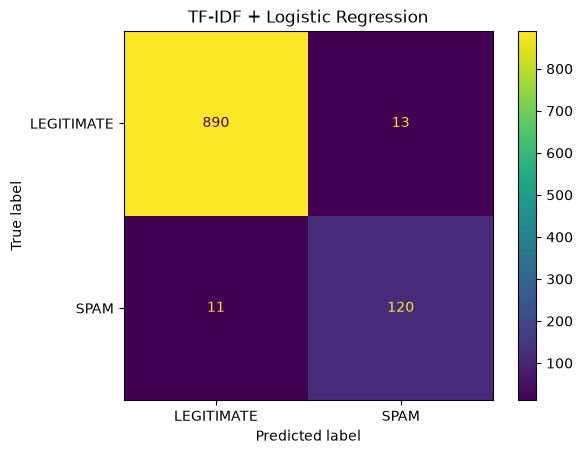

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["LEGITIMATE", "SPAM"]
)

disp.plot()

plt.title("TF-IDF + Logistic Regression")
plt.show()

## Machine Learning Baseline Results

### Model
TF-IDF + Logistic Regression

### Dataset Split
- 80% training
- 20% testing
- Stratified by class
- Random state: 42

### TF-IDF Configuration
- Unigrams and bigrams
- Minimum document frequency: 2
- Maximum document frequency: 95%

### Class Handling
Logistic Regression uses balanced class weights because the dataset contains more legitimate messages than spam.

### Evaluation
The model was evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

In [22]:
suspicious_keywords = [
    "free",
    "winner",
    "won",
    "prize",
    "claim",
    "urgent",
    "congratulations",
    "bonus",
    "offer",
    "cash",
    "reward"
]

urgency_keywords = [
    "urgent",
    "immediately",
    "now",
    "asap",
    "act now",
    "limited time"
]

financial_keywords = [
    "bank",
    "account",
    "payment",
    "credit",
    "debit",
    "money",
    "transfer"
]

In [23]:
def rule_based_classifier(message):
    text = str(message).lower()

    score = 0

    for keyword in suspicious_keywords:
        if keyword in text:
            score += 1

    for keyword in urgency_keywords:
        if keyword in text:
            score += 1

    for keyword in financial_keywords:
        if keyword in text:
            score += 1

    if re.search(r"https?://|www\.", text):
        score += 1

    if score >= 2:
        return 1

    return 0

In [24]:
rule_test_pred = X_test.apply(rule_based_classifier)

In [25]:
rule_accuracy = accuracy_score(
    y_test,
    rule_test_pred
)

rule_precision = precision_score(
    y_test,
    rule_test_pred
)

rule_recall = recall_score(
    y_test,
    rule_test_pred
)

rule_f1 = f1_score(
    y_test,
    rule_test_pred
)

print(f"Rule-based Accuracy:  {rule_accuracy:.4f}")
print(f"Rule-based Precision: {rule_precision:.4f}")
print(f"Rule-based Recall:    {rule_recall:.4f}")
print(f"Rule-based F1-score:  {rule_f1:.4f}")

Rule-based Accuracy:  0.9101
Rule-based Precision: 0.8276
Rule-based Recall:    0.3664
Rule-based F1-score:  0.5079


In [26]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Traditional Rules": [
        rule_accuracy,
        rule_precision,
        rule_recall,
        rule_f1
    ],
    "Machine Learning": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

comparison

,Metric,Traditional Rules,Machine Learning
0,Accuracy,0.910058,0.976789
1,Precision,0.827586,0.902256
2,Recall,0.366412,0.916031
3,F1-score,0.507937,0.909091


In [27]:
f1_improvement = f1 - rule_f1

print(f"F1-score improvement: {f1_improvement:.4f}")

F1-score improvement: 0.4012


In [28]:
if rule_f1 != 0:
    f1_improvement_percent = (
        (f1 - rule_f1) / rule_f1
    ) * 100

    print(
        f"F1-score percentage improvement: "
        f"{f1_improvement_percent:.2f}%"
    )

F1-score percentage improvement: 78.98%


In [1]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Traditional Programming": [
        rule_accuracy,
        rule_precision,
        rule_recall,
        rule_f1
    ],
    "Machine Learning": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

comparison

NameError: name 'pd' is not defined

In [2]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Traditional Programming": [
        rule_accuracy,
        rule_precision,
        rule_recall,
        rule_f1
    ],
    "Machine Learning": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

comparison

NameError: name 'pd' is not defined

In [3]:
f1_improvement = f1 - rule_f1

print(f"F1-score improvement: {f1_improvement:.4f}")

if rule_f1 != 0:
    f1_improvement_percent = (
        (f1 - rule_f1) / rule_f1
    ) * 100

    print(f"F1-score percentage improvement: {f1_improvement_percent:.2f}%")

NameError: name 'f1' is not defined

In [4]:
f1
rule_f1

NameError: name 'f1' is not defined

In [5]:
import pandas as pd

In [6]:
print("Pandas is ready")

Pandas is ready


In [7]:
file_path = "../data/processed/sms_spam_clean.csv"

df = pd.read_csv(file_path)

print("Dataset loaded:", df.shape)

Dataset loaded: (5169, 5)


In [8]:
X = df["message_clean"]
y = df["label_encoded"]

print("X samples:", len(X))
print("y samples:", len(y))

X samples: 5169
y samples: 5169


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF ready")
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

TF-IDF ready
Training shape: (4135, 10189)
Testing shape: (1034, 10189)


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("ML model trained successfully")

ML model trained successfully


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"ML Accuracy:  {accuracy:.4f}")
print(f"ML Precision: {precision:.4f}")
print(f"ML Recall:    {recall:.4f}")
print(f"ML F1-score:  {f1:.4f}")

ML Accuracy:  0.9768
ML Precision: 0.9023
ML Recall:    0.9160
ML F1-score:  0.9091


In [13]:
import re

suspicious_keywords = [
    "free",
    "winner",
    "won",
    "prize",
    "claim",
    "urgent",
    "congratulations",
    "bonus",
    "offer",
    "cash",
    "reward"
]

urgency_keywords = [
    "urgent",
    "immediately",
    "now",
    "asap",
    "act now",
    "limited time"
]

financial_keywords = [
    "bank",
    "account",
    "payment",
    "credit",
    "debit",
    "money",
    "transfer"
]

In [14]:
def rule_based_classifier(message):
    text = str(message).lower()

    score = 0

    for keyword in suspicious_keywords:
        if keyword in text:
            score += 1

    for keyword in urgency_keywords:
        if keyword in text:
            score += 1

    for keyword in financial_keywords:
        if keyword in text:
            score += 1

    if re.search(r"https?://|www\.", text):
        score += 1

    if score >= 2:
        return 1

    return 0

In [15]:
rule_test_pred = X_test.apply(rule_based_classifier)

print("Traditional predictions generated")

Traditional predictions generated


In [16]:
rule_accuracy = accuracy_score(
    y_test,
    rule_test_pred
)

rule_precision = precision_score(
    y_test,
    rule_test_pred
)

rule_recall = recall_score(
    y_test,
    rule_test_pred
)

rule_f1 = f1_score(
    y_test,
    rule_test_pred
)

print(f"Rule Accuracy:  {rule_accuracy:.4f}")
print(f"Rule Precision: {rule_precision:.4f}")
print(f"Rule Recall:    {rule_recall:.4f}")
print(f"Rule F1-score:  {rule_f1:.4f}")

Rule Accuracy:  0.9101
Rule Precision: 0.8276
Rule Recall:    0.3664
Rule F1-score:  0.5079


In [17]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Traditional Programming": [
        rule_accuracy,
        rule_precision,
        rule_recall,
        rule_f1
    ],
    "Machine Learning": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

comparison

,Metric,Traditional Programming,Machine Learning
0,Accuracy,0.910058,0.976789
1,Precision,0.827586,0.902256
2,Recall,0.366412,0.916031
3,F1-score,0.507937,0.909091


In [18]:
f1_improvement = f1 - rule_f1

print(f"F1-score improvement: {f1_improvement:.4f}")

F1-score improvement: 0.4012


In [19]:
if rule_f1 != 0:
    f1_improvement_percent = (
        (f1 - rule_f1) / rule_f1
    ) * 100

    print(
        f"F1-score percentage improvement: "
        f"{f1_improvement_percent:.2f}%"
    )

F1-score percentage improvement: 78.98%


In [20]:
for _, row in comparison.iterrows():
    traditional = row["Traditional Programming"]
    machine_learning = row["Machine Learning"]

    if machine_learning > traditional:
        winner = "Machine Learning"
    elif traditional > machine_learning:
        winner = "Traditional Programming"
    else:
        winner = "Tie"

    print(f"{row['Metric']}: {winner}")

Accuracy: Machine Learning
Precision: Machine Learning
Recall: Machine Learning
F1-score: Machine Learning


## Traditional Programming vs Machine Learning

Both approaches were evaluated using the same held-out test dataset.

### Traditional Programming

The traditional classifier uses manually defined rules based on suspicious keywords, urgency indicators, financial terminology, and URL detection.

### Machine Learning

The machine-learning classifier uses TF-IDF to transform text into numerical features and Logistic Regression to learn patterns from labeled examples.

### Experimental Approach

The same test messages were passed through both systems so their performance could be compared under the same conditions.

### Key Metrics

The systems were compared using:

- Accuracy
- Precision
- Recall
- F1-score

### Key Lesson

Traditional programming requires the developer to explicitly define rules.

Machine learning learns statistical patterns from examples.

The results from this experiment represent performance on this particular dataset and should not be interpreted as proof that one approach is universally superior.

In [21]:
ml_errors = df.loc[
    X_test.index[y_test != y_pred]
].copy()

print("Total ML errors:", len(ml_errors))

Total ML errors: 24


In [22]:
ml_errors[
    [
        "label",
        "message",
        "label_encoded"
    ]
].head(20)

,label,message,label_encoded
1262,ham,Your daily text from me – a favour this time,0
5137,spam,Want explicit SEX in 30 secs? Ring 02073162414...,1
3184,ham,I am waiting for your call sir.,0
4622,ham,I'm vivek:)i got call from your number.,0
5139,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1
487,ham,Are you free now?can i call now?,0
3599,ham,Please protect yourself from e-threats. SIB ne...,0
3481,ham,"Sir, i am waiting for your call, once free ple...",0
1423,spam,Hi its LUCY Hubby at meetins all day Fri & I w...,1
3949,spam,Missed call alert. These numbers called but le...,1


In [23]:
false_positives = df.loc[
    X_test.index[
        (y_test == 0) & (y_pred == 1)
    ]
]

print("False positives:", len(false_positives))

false_positives[
    ["label", "message"]
].head(20)

False positives: 13


,label,message
1262,ham,Your daily text from me – a favour this time
3184,ham,I am waiting for your call sir.
4622,ham,I'm vivek:)i got call from your number.
487,ham,Are you free now?can i call now?
3599,ham,Please protect yourself from e-threats. SIB ne...
3481,ham,"Sir, i am waiting for your call, once free ple..."
4806,ham,K k:) sms chat with me.
4299,ham,Have you laid your airtel line to rest?
1620,ham,Glad to see your reply.
2199,ham,Dont you have message offer


In [24]:
false_negatives = df.loc[
    X_test.index[
        (y_test == 1) & (y_pred == 0)
    ]
]

print("False negatives:", len(false_negatives))

false_negatives[
    ["label", "message"]
].head(20)

False negatives: 11


,label,message
5137,spam,Want explicit SEX in 30 secs? Ring 02073162414...
5139,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
1423,spam,Hi its LUCY Hubby at meetins all day Fri & I w...
3949,spam,Missed call alert. These numbers called but le...
2303,spam,Babe: U want me dont u baby! Im nasty and have...
3890,spam,In The Simpsons Movie released in July 2007 na...
5062,spam,"Latest News! Police station toilet stolen, cop..."
4185,spam,Want explicit SEX in 30 secs? Ring 02073162414...
1813,spam,Would you like to see my XXX pics they are so ...
3743,spam,ringtoneking 84484


In [25]:
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

In [26]:
probability_results = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": y_pred,
    "spam_probability": y_prob
})

probability_results.head(10)

,message,actual,predicted,spam_probability
4940,"good morning, my love ... i go to sleep now an...",0,0,0.078984
4908,"and how you will do that, princess? :)",0,0,0.064710
2358,"cool, i'll text you when i'm on the way",0,0,0.156673
1267,your right! i'll make the appointment right now.,0,0,0.211374
4738,aiya we discuss later lar... pick ü up at 4 is...,0,0,0.050165
666,maybe?! say hi to and find out if got his ca...,0,0,0.209995
4181,"lemme know when i can swing by and pick up, i'...",0,0,0.156293
5115,yes. please leave at &lt;#&gt; . so that at ...,0,0,0.025178
4614,i am in bus on the way to calicut,0,0,0.113071
4460,o we cant see if we can join denis and mina? o...,0,0,0.129763


In [27]:
probability_results["uncertainty"] = abs(
    probability_results["spam_probability"] - 0.5
)

In [28]:
uncertain_messages = probability_results.sort_values(
    "uncertainty"
)

uncertain_messages[
    [
        "message",
        "actual",
        "predicted",
        "spam_probability"
    ]
].head(20)

,message,actual,predicted,spam_probability
4299,have you laid your airtel line to rest?,0,1,0.507133
2565,i got a call from a landline number. . . i am ...,0,0,0.487081
1382,yes.. now only saw your message..,0,0,0.466642
1415,bought one ringtone and now getting texts cost...,1,1,0.534100
2465,now thats going to ruin your thesis!,0,0,0.454174
4806,k k:) sms chat with me.,0,1,0.548577
3522,plz note: if anyone calling from a mobile co. ...,0,0,0.448361
3400,cps is causing the outages to conserve energy.,0,0,0.441851
141,"sir, waiting for your mail.",0,0,0.440704
4530,i liked your new house,0,0,0.440319


## Error Analysis

The machine-learning classifier was evaluated at the individual prediction level to understand its failure modes.

### False Positives

False positives are legitimate messages incorrectly classified as spam.

Potential causes include overlapping vocabulary between legitimate and spam messages, short messages, and terms that frequently occur in spam.

### False Negatives

False negatives are spam messages incorrectly classified as legitimate.

These errors are particularly important for a security-oriented classifier because they represent spam messages that the system failed to identify.

Potential causes include unusual wording, uncommon vocabulary, and insufficient contextual information in the TF-IDF representation.

### Model Uncertainty

Prediction probabilities were examined to identify messages near the classification decision boundary.

These uncertain examples can help guide future model improvements and additional testing.

### Key Engineering Lesson

Aggregate metrics show overall performance, while error analysis helps explain why a model succeeds or fails.

In [29]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/logistic_regression_model.joblib"
)

joblib.dump(
    vectorizer,
    "../models/tfidf_vectorizer.joblib"
)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [30]:
def predict_message(message):
    cleaned_message = str(message).lower()

    transformed_message = vectorizer.transform(
        [cleaned_message]
    )

    prediction = model.predict(
        transformed_message
    )[0]

    probability = model.predict_proba(
        transformed_message
    )[0][1]

    return prediction, probability

In [31]:
message = "Congratulations! You have won a free reward. Claim now!"

prediction, probability = predict_message(message)

print(
    "Prediction:",
    "SPAM" if prediction == 1 else "LEGITIMATE"
)

print(f"Spam probability: {probability:.2%}")

Prediction: SPAM
Spam probability: 96.90%


In [32]:
message = "Hi, are you coming to class today?"

prediction, probability = predict_message(message)

print(
    "Prediction:",
    "SPAM" if prediction == 1 else "LEGITIMATE"
)

print(f"Spam probability: {probability:.2%}")

Prediction: LEGITIMATE
Spam probability: 10.55%


In [33]:
from sklearn.naive_bayes import MultinomialNB

In [34]:
nb_model = MultinomialNB()

print("Naive Bayes model created successfully.")

Naive Bayes model created successfully.


In [35]:
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [36]:
nb_pred = nb_model.predict(X_test_tfidf)

print(nb_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [37]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy:  {nb_accuracy:.4f}")
print(f"Naive Bayes Precision: {nb_precision:.4f}")
print(f"Naive Bayes Recall:    {nb_recall:.4f}")
print(f"Naive Bayes F1-score:  {nb_f1:.4f}")

Naive Bayes Accuracy:  0.9623
Naive Bayes Precision: 1.0000
Naive Bayes Recall:    0.7023
Naive Bayes F1-score:  0.8251


In [38]:
print(
    classification_report(
        y_test,
        nb_pred,
        target_names=["LEGITIMATE", "SPAM"]
    )
)

NameError: name 'classification_report' is not defined

In [39]:
from sklearn.metrics import classification_report

In [40]:
print("classification_report is ready")

classification_report is ready


In [41]:
print(
    classification_report(
        y_test,
        nb_pred,
        target_names=["LEGITIMATE", "SPAM"]
    )
)

              precision    recall  f1-score   support

  LEGITIMATE       0.96      1.00      0.98       903
        SPAM       1.00      0.70      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



In [42]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Traditional Programming": [
        rule_accuracy,
        rule_precision,
        rule_recall,
        rule_f1
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Multinomial Naive Bayes": [
        nb_accuracy,
        nb_precision,
        nb_recall,
        nb_f1
    ]
})

model_comparison

,Metric,Traditional Programming,Logistic Regression,Multinomial Naive Bayes
0,Accuracy,0.910058,0.976789,0.962282
1,Precision,0.827586,0.902256,1.000000
2,Recall,0.366412,0.916031,0.702290
3,F1-score,0.507937,0.909091,0.825112


In [43]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Traditional Programming": [
        rule_accuracy,
        rule_precision,
        rule_recall,
        rule_f1
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Multinomial Naive Bayes": [
        nb_accuracy,
        nb_precision,
        nb_recall,
        nb_f1
    ]
})

model_comparison

,Metric,Traditional Programming,Logistic Regression,Multinomial Naive Bayes
0,Accuracy,0.910058,0.976789,0.962282
1,Precision,0.827586,0.902256,1.000000
2,Recall,0.366412,0.916031,0.702290
3,F1-score,0.507937,0.909091,0.825112


In [44]:
f1_scores = {
    "Traditional Programming": rule_f1,
    "Logistic Regression": f1,
    "Multinomial Naive Bayes": nb_f1
}

best_model = max(
    f1_scores,
    key=f1_scores.get
)

print("Best model by F1-score:", best_model)
print(f"F1-score: {f1_scores[best_model]:.4f}")

Best model by F1-score: Logistic Regression
F1-score: 0.9091


In [45]:
print("Traditional Programming spam recall:", f"{rule_recall:.4f}")
print("Logistic Regression spam recall:", f"{recall:.4f}")
print("Multinomial Naive Bayes spam recall:", f"{nb_recall:.4f}")

Traditional Programming spam recall: 0.3664
Logistic Regression spam recall: 0.9160
Multinomial Naive Bayes spam recall: 0.7023


In [46]:
spam_recall_scores = {
    "Traditional Programming": rule_recall,
    "Logistic Regression": recall,
    "Multinomial Naive Bayes": nb_recall
}

best_recall_model = max(
    spam_recall_scores,
    key=spam_recall_scores.get
)

print(
    "Best model by spam recall:",
    best_recall_model
)

Best model by spam recall: Logistic Regression


In [47]:
import matplotlib.pyplot as plt

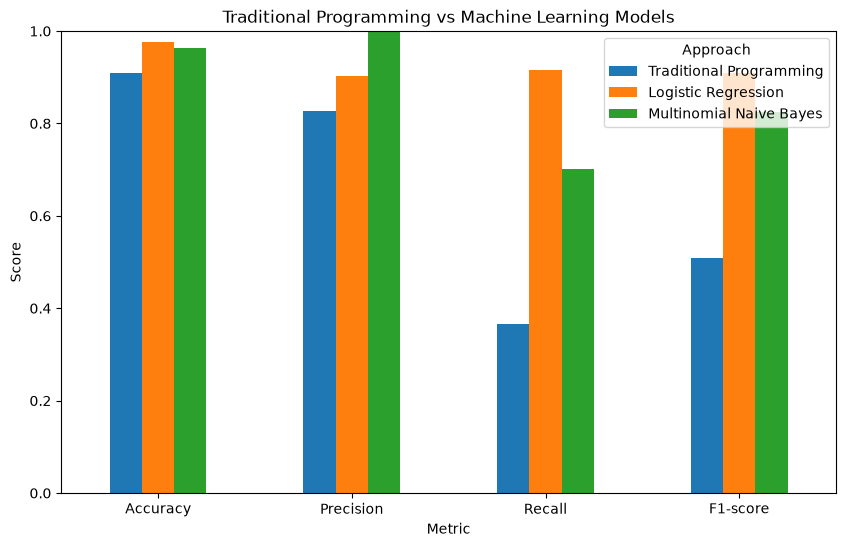

In [48]:
model_comparison_plot = model_comparison.set_index("Metric")

model_comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Traditional Programming vs Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Approach")
plt.show()

In [49]:
nb_cm = confusion_matrix(y_test, nb_pred)

nb_disp = ConfusionMatrixDisplay(
    confusion_matrix=nb_cm,
    display_labels=["LEGITIMATE", "SPAM"]
)

nb_disp.plot()

plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

NameError: name 'confusion_matrix' is not defined

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Confusion matrix tools are ready")

Confusion matrix tools are ready


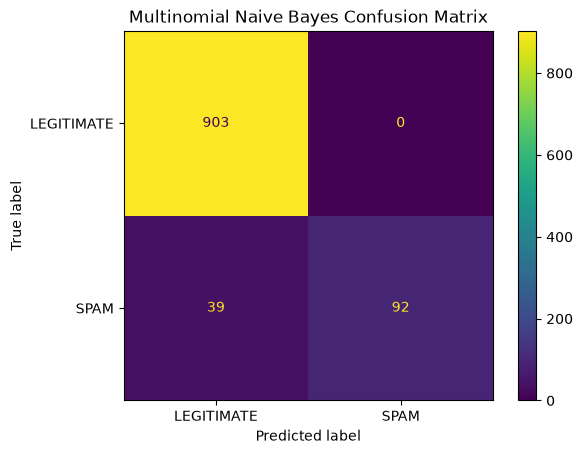

In [51]:
nb_cm = confusion_matrix(y_test, nb_pred)

nb_disp = ConfusionMatrixDisplay(
    confusion_matrix=nb_cm,
    display_labels=["LEGITIMATE", "SPAM"]
)

nb_disp.plot()

plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

In [52]:
lr_cm = confusion_matrix(y_test, y_pred)
nb_cm = confusion_matrix(y_test, nb_pred)

lr_false_negatives = lr_cm[1, 0]
nb_false_negatives = nb_cm[1, 0]

print("Logistic Regression false negatives:", lr_false_negatives)
print("Naive Bayes false negatives:", nb_false_negatives)

Logistic Regression false negatives: 11
Naive Bayes false negatives: 39


In [53]:
lr_false_positives = lr_cm[0, 1]
nb_false_positives = nb_cm[0, 1]

print("Logistic Regression false positives:", lr_false_positives)
print("Naive Bayes false positives:", nb_false_positives)

Logistic Regression false positives: 13
Naive Bayes false positives: 0


## Model Comparison Findings

Three approaches were evaluated:

1. Traditional rule-based programming
2. TF-IDF + Logistic Regression
3. TF-IDF + Multinomial Naive Bayes

All approaches were evaluated on the same held-out test set.

### Primary Selection Metric

F1-score was used as the primary model-selection metric because it balances precision and recall.

### Security Consideration

Spam recall was also examined because false negatives represent spam messages that the classifier failed to identify.

### Observations

The final model should not be selected solely on accuracy.

The selection should consider:
- F1-score
- spam precision
- spam recall
- false positives
- false negatives
- practical deployment considerations

In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [55]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [56]:
lr_cv_scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression CV F1 scores:")
print(lr_cv_scores)

print(
    f"Mean CV F1: "
    f"{lr_cv_scores.mean():.4f}"
)

print(
    f"Standard deviation: "
    f"{lr_cv_scores.std():.4f}"
)

Logistic Regression CV F1 scores:
[0.91176471 0.94117647 0.94059406 0.94230769 0.93396226]
Mean CV F1: 0.9340
Standard deviation: 0.0115


In [57]:
nb_cv_scores = cross_val_score(
    nb_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Naive Bayes CV F1 scores:")
print(nb_cv_scores)

print(
    f"Mean CV F1: "
    f"{nb_cv_scores.mean():.4f}"
)

print(
    f"Standard deviation: "
    f"{nb_cv_scores.std():.4f}"
)

Naive Bayes CV F1 scores:
[0.82485876 0.83798883 0.83798883 0.85869565 0.80681818]
Mean CV F1: 0.8333
Standard deviation: 0.0171


In [58]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Mean CV F1": [
        lr_cv_scores.mean(),
        nb_cv_scores.mean()
    ],
    "CV F1 Std": [
        lr_cv_scores.std(),
        nb_cv_scores.std()
    ]
})

cv_comparison

,Model,Mean CV F1,CV F1 Std
0,Logistic Regression,0.933961,0.011475
1,Multinomial Naive Bayes,0.833270,0.017096


In [59]:
cv_f1_scores = {
    "Logistic Regression": lr_cv_scores.mean(),
    "Multinomial Naive Bayes": nb_cv_scores.mean()
}

best_cv_model = max(
    cv_f1_scores,
    key=cv_f1_scores.get
)

print("Best model by mean CV F1:", best_cv_model)
print(
    f"Mean CV F1: "
    f"{cv_f1_scores[best_cv_model]:.4f}"
)

Best model by mean CV F1: Logistic Regression
Mean CV F1: 0.9340


In [60]:
cv_std_scores = {
    "Logistic Regression": lr_cv_scores.std(),
    "Multinomial Naive Bayes": nb_cv_scores.std()
}

most_stable_model = min(
    cv_std_scores,
    key=cv_std_scores.get
)

print("Most stable model:", most_stable_model)
print(
    f"CV F1 standard deviation: "
    f"{cv_std_scores[most_stable_model]:.4f}"
)

Most stable model: Logistic Regression
CV F1 standard deviation: 0.0115


In [61]:
LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
param_grid = {
    "C": [0.1, 0.5, 1, 2, 5],
    "class_weight": ["balanced", None]
}

In [64]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

In [65]:
grid_search.fit(
    X_train_tfidf,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.5, ...], 'class_weight': ['balanced', None]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls th

In [66]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'C': 5, 'class_weight': 'balanced'}


In [67]:
print(
    f"Best cross-validation F1: "
    f"{grid_search.best_score_:.4f}"
)

Best cross-validation F1: 0.9366


In [68]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_results[
    [
        "param_C",
        "param_class_weight",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_C,param_class_weight,mean_test_score,std_test_score,rank_test_score
8,5.0,balanced,0.936597,0.011111,1
6,2.0,balanced,0.934885,0.010084,2
4,1.0,balanced,0.933961,0.011475,3
2,0.5,balanced,0.931387,0.010433,4
0,0.1,balanced,0.917542,0.014373,5
9,5.0,NaN,0.893526,0.022515,6
7,2.0,NaN,0.837494,0.026877,7
5,1.0,NaN,0.741918,0.047840,8
3,0.5,NaN,0.441049,0.071662,9
1,0.1,NaN,0.000000,0.000000,10


In [69]:
best_lr_model = grid_search.best_estimator_

In [70]:
print(best_lr_model)

LogisticRegression(C=5, class_weight='balanced', max_iter=1000, random_state=42)


In [71]:
tuned_pred = best_lr_model.predict(
    X_test_tfidf
)

In [72]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred
)

print(f"Tuned Accuracy:  {tuned_accuracy:.4f}")
print(f"Tuned Precision: {tuned_precision:.4f}")
print(f"Tuned Recall:    {tuned_recall:.4f}")
print(f"Tuned F1-score:  {tuned_f1:.4f}")

Tuned Accuracy:  0.9787
Tuned Precision: 0.9160
Tuned Recall:    0.9160
Tuned F1-score:  0.9160


In [73]:
tuning_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Original Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Tuned Logistic Regression": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

tuning_comparison

,Metric,Original Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.976789,0.978723
1,Precision,0.902256,0.916031
2,Recall,0.916031,0.916031
3,F1-score,0.909091,0.916031


In [74]:
TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.95
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'


In [75]:
from sklearn.pipeline import Pipeline

In [76]:
tfidf_lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

print("TF-IDF + Logistic Regression pipeline created.")

TF-IDF + Logistic Regression pipeline created.


In [77]:
pipeline_param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        1,
        2,
        3
    ],

    "tfidf__max_df": [
        0.95,
        1.0
    ],

    "classifier__C": [
        0.5,
        1,
        2
    ],

    "classifier__class_weight": [
        "balanced",
        None
    ]
}

In [78]:
tfidf_grid_search = GridSearchCV(
    estimator=tfidf_lr_pipeline,
    param_grid=pipeline_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [79]:
tfidf_grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.5, 1, ...], 'classifier__class_weight': ['balanced', None], 'tfidf__max_df': [0.95, 1.0], 'tfidf__min_df': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multi

In [80]:
print("Best parameters:")
print(tfidf_grid_search.best_params_)

Best parameters:
{'classifier__C': 2, 'classifier__class_weight': 'balanced', 'tfidf__max_df': 0.95, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}


In [81]:
print(
    f"Best CV F1: "
    f"{tfidf_grid_search.best_score_:.4f}"
)

Best CV F1: 0.9380


In [82]:
best_pipeline = tfidf_grid_search.best_estimator_

In [83]:
pipeline_pred = best_pipeline.predict(X_test)

In [84]:
pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_pred
)

pipeline_precision = precision_score(
    y_test,
    pipeline_pred
)

pipeline_recall = recall_score(
    y_test,
    pipeline_pred
)

pipeline_f1 = f1_score(
    y_test,
    pipeline_pred
)

print(f"Pipeline Accuracy:  {pipeline_accuracy:.4f}")
print(f"Pipeline Precision: {pipeline_precision:.4f}")
print(f"Pipeline Recall:    {pipeline_recall:.4f}")
print(f"Pipeline F1-score:  {pipeline_f1:.4f}")

Pipeline Accuracy:  0.9778
Pipeline Precision: 0.9154
Pipeline Recall:    0.9084
Pipeline F1-score:  0.9119


In [85]:
final_candidate_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Original Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1
    ],

    "Tuned Logistic Regression": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ],

    "Multinomial Naive Bayes": [
        nb_accuracy,
        nb_precision,
        nb_recall,
        nb_f1
    ],

    "Tuned TF-IDF + Logistic Regression": [
        pipeline_accuracy,
        pipeline_precision,
        pipeline_recall,
        pipeline_f1
    ]
})

final_candidate_comparison

,Metric,Original Logistic Regression,Tuned Logistic Regression,Multinomial Naive Bayes,Tuned TF-IDF + Logistic Regression
0,Accuracy,0.976789,0.978723,0.962282,0.977756
1,Precision,0.902256,0.916031,1.000000,0.915385
2,Recall,0.916031,0.916031,0.702290,0.908397
3,F1-score,0.909091,0.916031,0.825112,0.911877


In [86]:
candidate_f1_scores = {
    "Original Logistic Regression": f1,
    "Tuned Logistic Regression": tuned_f1,
    "Multinomial Naive Bayes": nb_f1,
    "Tuned TF-IDF + Logistic Regression": pipeline_f1
}

best_candidate = max(
    candidate_f1_scores,
    key=candidate_f1_scores.get
)

print("Best candidate by F1-score:", best_candidate)
print(
    f"F1-score: "
    f"{candidate_f1_scores[best_candidate]:.4f}"
)

Best candidate by F1-score: Tuned Logistic Regression
F1-score: 0.9160


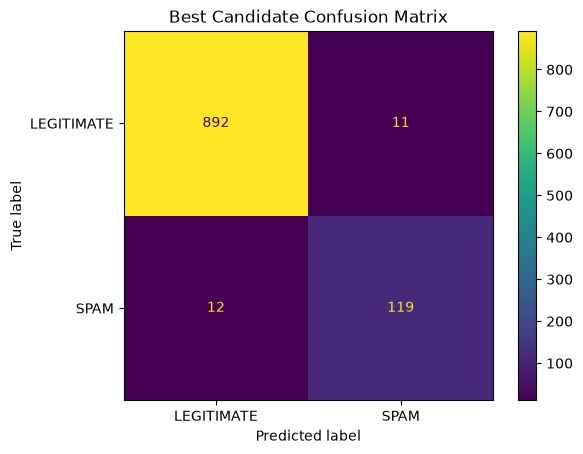

In [87]:
best_cm = confusion_matrix(
    y_test,
    pipeline_pred
)

best_disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=["LEGITIMATE", "SPAM"]
)

best_disp.plot()

plt.title("Best Candidate Confusion Matrix")
plt.show()

In [88]:
best_false_negatives = best_cm[1, 0]
best_false_positives = best_cm[0, 1]

print("False negatives:", best_false_negatives)
print("False positives:", best_false_positives)

False negatives: 12
False positives: 11


## Final Model Selection

The project evaluated multiple approaches:

1. Traditional rule-based programming
2. TF-IDF + Logistic Regression
3. TF-IDF + Multinomial Naive Bayes
4. Tuned Logistic Regression
5. Tuned TF-IDF + Logistic Regression

Model selection considers:

- F1-score
- Spam precision
- Spam recall
- False positives
- False negatives
- Cross-validation performance
- Model complexity

F1-score is used as the primary metric because it balances precision and recall.

Spam recall is also considered important because false negatives represent spam messages that were not detected.

The final model is selected based on the experimental evidence rather than assuming that a particular algorithm will always perform best.

In [89]:
import joblib

joblib.dump(
    best_pipeline,
    "../models/final_phishing_classifier.joblib"
)

print("Final phishing classifier saved successfully.")

Final phishing classifier saved successfully.


In [90]:
final_model = joblib.load(
    "../models/final_phishing_classifier.joblib"
)

print("Final model loaded successfully.")

Final model loaded successfully.


In [91]:
def classify_message(message):
    prediction = final_model.predict(
        [message]
    )[0]

    probability = final_model.predict_proba(
        [message]
    )[0][1]

    return prediction, probability

In [92]:
message = "Congratulations! You have won a free reward. Claim now!"

prediction, probability = classify_message(message)

print(
    "Prediction:",
    "SPAM" if prediction == 1 else "LEGITIMATE"
)

print(f"Spam probability: {probability:.2%}")

Prediction: SPAM
Spam probability: 98.31%


In [93]:
message = "Hi, are you coming to class today?"

prediction, probability = classify_message(message)

print(
    "Prediction:",
    "SPAM" if prediction == 1 else "LEGITIMATE"
)

print(f"Spam probability: {probability:.2%}")

Prediction: LEGITIMATE
Spam probability: 5.45%
